# Experiment 4: AISO as Representation Learner

## 실험 설계 원칙
모든 비교는 동일 조건에서 피처/전략 차이만 변경.

| 실험 | 학습 데이터 | 조건 | 핵심 질문 |
|------|-----------|------|---------|
| **4a** W→LR | sel_n(10000 licit) + illicit 전체 | LR vs LR+W_j (동일 데이터) | W_j가 추가 정보 주는가? |
| **4b** Active Learning | sel_n + 라운드별 illicit 누적 | Random vs AISO-Entropy | W 엔트로피가 더 나은 쿼리인가? |
| **4c** Anomaly Detection | licit 3000개만 (비지도) | AISO vs IF vs LOF | bilinear score가 이상 탐지에 유효한가? |

GCN(exp1b, 0.6041)과 4a LR의 직접 비교는 **하지 않음** — transductive vs inductive 구조 차이.


In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from sklearn.preprocessing import MinMaxScaler as MMS, StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt, copy, warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE   = r'c:\Users\kevin\OneDrive\Desktop\AISO\Elliptic Bitcoin\elliptic_bitcoin_dataset'
SEED   = 42

feat_df = pd.read_csv(f'{BASE}/elliptic_txs_features.csv', header=None)
cls_df  = pd.read_csv(f'{BASE}/elliptic_txs_classes.csv')
edge_df = pd.read_csv(f'{BASE}/elliptic_txs_edgelist.csv')
feat_df.columns = ['txId'] + [f'f{i}' for i in range(1,167)]
feat_df['timestep'] = feat_df['f1'].astype(int)
df = feat_df.merge(cls_df, on='txId')
labeled = df[df['class'] != 'unknown'].copy().reset_index(drop=True)
labeled['y'] = (labeled['class'] == '1').astype(int)
feat_cols = [f'f{i}' for i in range(1,167)]
X_all  = labeled[feat_cols].values.astype(float)
y_all  = labeled['y'].values
ts_all = labeled['timestep'].values
N_NODES = len(labeled)
X_scaled = StandardScaler().fit_transform(X_all)

txid_map = {tid: i for i, tid in enumerate(labeled['txId'].values)}
src_list, dst_list = [], []
for _, row in edge_df.iterrows():
    s, d = txid_map.get(row['txId1']), txid_map.get(row['txId2'])
    if s is not None and d is not None:
        src_list.append(s); dst_list.append(d)
src_arr = np.array(src_list); dst_arr = np.array(dst_list)

train_mask = ts_all <= 34; test_mask = ts_all > 34
train_illicit_idx = np.where(train_mask & (y_all==1))[0]
train_licit_idx   = np.where(train_mask & (y_all==0))[0]
test_idx          = np.where(test_mask)[0]
N_LICIT = 10000

# exp1b 동일: sel_n SEED=42 고정
sel_n = np.random.RandomState(SEED).choice(train_licit_idx, N_LICIT, replace=False)

print(f"N_NODES={N_NODES}  illicit={len(train_illicit_idx)}  licit={len(train_licit_idx)}")
print(f"sel_n={len(sel_n)}  test={len(test_idx)} (illicit={y_all[test_idx].sum()})")


c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


N_NODES=46564  illicit=3462  licit=26432
sel_n=10000  test=16670 (illicit=1083)


In [2]:
# Dom-12 (exp1b d003 동일)
src_bi = np.concatenate([src_arr,dst_arr]); dst_bi = np.concatenate([dst_arr,src_arr])
node_degree = np.bincount(src_bi, minlength=N_NODES).astype(float)
illicit_lbl = y_all.astype(float)
ill_ns = np.zeros(N_NODES); np.add.at(ill_ns, src_bi, illicit_lbl[dst_bi])
illicit_neigh_ratio = ill_ns / np.maximum(node_degree,1)
n2i = np.zeros(N_NODES); np.add.at(n2i, src_bi, illicit_neigh_ratio[dst_bi])
neigh2_illicit = n2i / np.maximum(node_degree,1)
hub_fraud = node_degree * illicit_neigh_ratio
ts_rate = {t: y_all[ts_all==t].mean() for t in np.unique(ts_all)}
node_ts_rate = np.array([ts_rate[t] for t in ts_all])
ts_norm = (ts_all-ts_all.min()) / max(ts_all.max()-ts_all.min(),1)
lf = X_scaled[:,1:94]; af = X_scaled[:,94:166]
domain_norm_12 = MMS().fit_transform(np.stack([
    node_degree, illicit_neigh_ratio, neigh2_illicit, node_ts_rate,
    lf.mean(1), lf.std(1), lf.max(1), af.mean(1), af.std(1), af.max(1),
    ts_norm, hub_fraud], axis=1))
print(f"Dom-12: {domain_norm_12.shape}")


Dom-12: (46564, 12)


In [3]:
# evaluate_gnn — exp1b showdown 프로토콜 완전 동일
# X_scaled(166d), train-loss early stop(patience=20), weight_decay=5e-4
ei_np = np.array([np.concatenate([src_arr,dst_arr]),
                   np.concatenate([dst_arr,src_arr])])
_LOOKUP = np.full(N_NODES, -1, dtype=np.int32)

class GCN(torch.nn.Module):
    def __init__(self, in_ch, hidden=64, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_ch, hidden)
        self.conv2 = GCNConv(hidden, hidden)
        self.lin   = torch.nn.Linear(hidden, 2)
        self.drop  = dropout
    def forward(self, x, ei):
        x = F.relu(self.conv1(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        x = F.relu(self.conv2(x, ei))
        x = F.dropout(x, p=self.drop, training=self.training)
        return self.lin(x)

def evaluate_gnn(sel_pool_idx, label=''):
    uniq_anom       = np.unique(sel_pool_idx)
    sel_anom_global = train_illicit_idx[uniq_anom]
    test_global     = np.where(test_mask)[0]
    sub_nodes = np.unique(np.concatenate([sel_n, sel_anom_global, test_global]))
    n_sub = len(sub_nodes)
    _LOOKUP[:] = -1; _LOOKUP[sub_nodes] = np.arange(n_sub)
    sl = _LOOKUP[ei_np[0]]; dl = _LOOKUP[ei_np[1]]
    ok = (sl>=0)&(dl>=0)
    ei_sub = torch.tensor([sl[ok],dl[ok]], dtype=torch.long).to(DEVICE)
    X_sub  = torch.from_numpy(X_scaled[sub_nodes]).float().to(DEVICE)
    y_sub  = torch.from_numpy(y_all[sub_nodes]).long().to(DEVICE)
    tr_set = set(np.concatenate([sel_n, sel_anom_global]).tolist())
    te_set = set(test_global.tolist())
    tr_mask = torch.tensor([g in tr_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    te_mask = torch.tensor([g in te_set for g in sub_nodes], dtype=torch.bool).to(DEVICE)
    n0 = int((y_all[sub_nodes][tr_mask.cpu().numpy()]==0).sum())
    n1 = int((y_all[sub_nodes][tr_mask.cpu().numpy()]==1).sum())
    cw = torch.tensor([1.0, n0/max(n1,1)], dtype=torch.float).to(DEVICE)
    torch.manual_seed(SEED)
    model = GCN(X_scaled.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    best_loss, best_state, patience = float('inf'), None, 0
    for ep in range(200):
        model.train(); opt.zero_grad()
        loss = F.cross_entropy(model(X_sub,ei_sub)[tr_mask], y_sub[tr_mask], weight=cw)
        loss.backward(); opt.step()
        if loss.item() < best_loss:
            best_loss=loss.item(); best_state=copy.deepcopy(model.state_dict()); patience=0
        else:
            patience+=1
        if patience>=20: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        prob = F.softmax(model(X_sub,ei_sub),1)[:,1].cpu().numpy()
    tc = te_mask.cpu().numpy()
    pr  = average_precision_score(y_all[sub_nodes][tc], prob[tc])
    f1  = f1_score(y_all[sub_nodes][tc],(prob[tc]>0.5).astype(int),zero_division=0)
    auc = roc_auc_score(y_all[sub_nodes][tc], prob[tc])
    if label: print(f'  {label:<28} PR-AUC={pr:.4f}')
    return {'PR-AUC':pr, 'F1':f1, 'AUC':auc}

print("evaluate_gnn 준비 완료 (exp1b 프로토콜 동일)")


evaluate_gnn 준비 완료 (exp1b 프로토콜 동일)


In [4]:
# AISO Phase 1-2: Dom-12 공간에서 W_j 학습
def learn_w(X_nodes, SEED=42, N_AG=20, N_IT=80, K=8,
            ALPHA=0.2, BETA=0.08, M_LOW=-0.5, W_REPEL=2.0):
    rng = np.random.RandomState(SEED)
    n, d = X_nodes.shape
    init_idx = rng.choice(n, N_AG, replace=True)
    X_ag = X_nodes[init_idx].copy().astype(float)
    W_ag = rng.dirichlet(np.ones(K), N_AG)
    M    = rng.uniform(M_LOW, W_REPEL, (K, K))
    w_r  = W_REPEL
    for t in range(N_IT):
        if t % 10 == 0:
            div = np.mean([np.linalg.norm(X_ag[i]-X_ag[j])
                           for i in range(N_AG) for j in range(i+1,N_AG)])
            w_r = 1.0 + 3.0*np.exp(-div/0.12)
        C = W_ag @ M @ W_ag.T; np.fill_diagonal(C, 0)
        for i in range(N_AG):
            ci=C[i].copy(); ci[i]=0
            ta=np.argsort(ci)[-3:]; tr=np.argsort(ci)[:3]
            Fv=(sum(ci[j]*(X_ag[j]-X_ag[i]) for j in ta)
               +w_r*sum(ci[j]*(X_ag[j]-X_ag[i]) for j in tr))/6.0
            nn=np.argmin(np.linalg.norm(X_nodes-np.clip(X_ag[i]+ALPHA*Fv,0,1),axis=1))
            X_ag[i]=X_nodes[nn]
            bj=ta[np.argmax(ci[ta])]
            W_ag[i]=(1-BETA)*W_ag[i]+BETA*W_ag[bj]; W_ag[i]/=W_ag[i].sum()
    reg = Ridge(alpha=0.1).fit(X_ag, W_ag)
    W_all = reg.predict(X_nodes)
    W_all = np.maximum(W_all,1e-8); W_all/=W_all.sum(1,keepdims=True)
    return W_all, W_ag, M

print("W 학습 중...")
W_all, W_ag_learned, M_learned = learn_w(domain_norm_12)
print(f"W_all: {W_all.shape}  K=8 타입 벡터 전체 노드")


W 학습 중...
W_all: (46564, 8)  K=8 타입 벡터 전체 노드


## Exp 4a: W → LR

**조건**: sel_n(10000 licit) + train_illicit 전체(4545) → LR 학습 → test set 평가
GCN과 같은 licit 풀 사용. illicit은 AISO 샘플링 없이 전체 사용 (LR은 샘플링 불필요).
피처 차이만 비교 → W_j가 X_scaled / Dom-12에 추가 정보 주는가?
GCN과 직접 비교 안 함 (transductive vs inductive).


In [5]:
# 학습: sel_n(10000 licit) + 전체 illicit
train_lr_idx = np.concatenate([sel_n, train_illicit_idx])
y_tr = y_all[train_lr_idx]
y_te = y_all[test_idx]

X_raw_tr = X_scaled[train_lr_idx];      X_raw_te = X_scaled[test_idx]
X_dom_tr = domain_norm_12[train_lr_idx]; X_dom_te = domain_norm_12[test_idx]
X_w_tr   = W_all[train_lr_idx];          X_w_te   = W_all[test_idx]
X_dw_tr  = np.hstack([X_dom_tr, X_w_tr]); X_dw_te = np.hstack([X_dom_te, X_w_te])
X_rw_tr  = np.hstack([X_raw_tr, X_w_tr]); X_rw_te = np.hstack([X_raw_te, X_w_te])

n0=(y_tr==0).sum(); n1=(y_tr==1).sum()
cw_lr = {0:1, 1:n0/n1}

configs = [
    ("LR (X_scaled 166d)",       X_raw_tr, X_raw_te),
    ("LR (Dom-12)",              X_dom_tr, X_dom_te),
    ("LR (W_j only K=8)",        X_w_tr,   X_w_te),
    ("LR (Dom-12 + W_j)",        X_dw_tr,  X_dw_te),
    ("LR (X_scaled + W_j)",      X_rw_tr,  X_rw_te),
]

print(f"학습: sel_n {len(sel_n):,} licit + {len(train_illicit_idx):,} illicit")
print(f"{'방법':<26} {'PR-AUC':>8} {'F1':>7} {'AUC':>7}")
print("-" * 52)
lr_results = {}
for name, X_tr, X_te in configs:
    lr = LogisticRegression(max_iter=1000, class_weight=cw_lr, solver='saga')
    lr.fit(X_tr, y_tr)
    prob = lr.predict_proba(X_te)[:,1]
    pr  = average_precision_score(y_te, prob)
    f1v = f1_score(y_te,(prob>0.5).astype(int),zero_division=0)
    auc = roc_auc_score(y_te, prob)
    lr_results[name] = pr
    base = lr_results.get("LR (X_scaled 166d)", 0)
    flag = " ★" if pr > base and name != "LR (X_scaled 166d)" else ""
    print(f"  {name:<24} {pr:>8.4f} {f1v:>7.4f} {auc:>7.4f}{flag}")
print()
print("  GCN(X_scaled, AISO Dom-12) 0.6041  ← exp1b (transductive, 샘플링)")
print("  ※ LR은 inductive + illicit 전체 사용 → GCN과 직접 비교 불가")
print("  ※ 행 간 비교만 유효: W_j 추가 시 개선 여부")


학습: sel_n 10,000 licit + 3,462 illicit
방법                           PR-AUC      F1     AUC
----------------------------------------------------
  LR (X_scaled 166d)         0.3706  0.2562  0.8943
  LR (Dom-12)                0.6951  0.6043  0.9308 ★
  LR (W_j only K=8)          0.5084  0.1221  0.7010 ★
  LR (Dom-12 + W_j)          0.6938  0.6067  0.9305 ★
  LR (X_scaled + W_j)        0.6843  0.3423  0.9513 ★

  GCN(X_scaled, AISO Dom-12) 0.6041  ← exp1b (transductive, 샘플링)
  ※ LR은 inductive + illicit 전체 사용 → GCN과 직접 비교 불가
  ※ 행 간 비교만 유효: W_j 추가 시 개선 여부


## Exp 4b: Active Learning

**설정**: 초기 50 illicit → 라운드당 30 쿼리 추가 → 각 라운드 evaluate_gnn (exp1b 프로토콜)
**전략 비교**: Random vs AISO-Entropy(H(W_j) 높은 노드) vs AISO-Low(bilinear score 낮은 노드)
licit은 항상 sel_n(10000, 고정) — GCN baseline과 동일 조건.


In [6]:
ROUNDS    = 6
Q_PER_RND = 30
rng_al    = np.random.RandomState(0)

# illicit 풀 전체에 대해 AISO 지표 계산
W_ill  = W_all[train_illicit_idx]          # (N_ill, K=8)
H_ill  = -np.sum(W_ill*np.log(W_ill+1e-10), axis=1)  # 엔트로피

# proto_W 없으므로 K-Means로 K=8 proto 생성
from sklearn.cluster import KMeans
km_proto = KMeans(8, random_state=SEED, n_init=10).fit(W_ag_learned)
proto_W  = km_proto.cluster_centers_
proto_W /= proto_W.sum(1, keepdims=True)
# bilinear score: max_c proto_W @ M @ W_j
score_ill = np.array([np.max(proto_W @ M_learned @ W_ill[j]) for j in range(len(train_illicit_idx))])

init_pool = rng_al.choice(len(train_illicit_idx), 50, replace=False)

def run_al(init_pool, strategy):
    pool      = list(init_pool)
    unlabeled = list(np.setdiff1d(np.arange(len(train_illicit_idx)), pool))
    curve     = []
    for r in range(ROUNDS):
        res = evaluate_gnn(np.array(pool))
        curve.append(res['PR-AUC'])
        print(f"  [{strategy:<14}] round {r+1}  pool={len(pool):3d}  PR-AUC={res['PR-AUC']:.4f}")
        if len(unlabeled) < Q_PER_RND: break
        ul = np.array(unlabeled)
        if strategy == 'Random':
            chosen = rng_al.choice(len(ul), Q_PER_RND, replace=False)
        elif strategy == 'AISO-Entropy':
            chosen = np.argsort(H_ill[ul])[-Q_PER_RND:]
        elif strategy == 'AISO-Low':
            chosen = np.argsort(score_ill[ul])[:Q_PER_RND]
        sel = ul[chosen]
        pool += sel.tolist()
        unlabeled = list(np.setdiff1d(ul, sel))
    return curve

curves = {}
for strat in ['Random', 'AISO-Entropy', 'AISO-Low']:
    print(f"--- {strat} ---")
    curves[strat] = run_al(init_pool.copy(), strat)
    print()


--- Random ---
  [Random        ] round 1  pool= 50  PR-AUC=0.5531
  [Random        ] round 2  pool= 80  PR-AUC=0.5853
  [Random        ] round 3  pool=110  PR-AUC=0.4971
  [Random        ] round 4  pool=140  PR-AUC=0.5803
  [Random        ] round 5  pool=170  PR-AUC=0.5274
  [Random        ] round 6  pool=200  PR-AUC=0.3841

--- AISO-Entropy ---
  [AISO-Entropy  ] round 1  pool= 50  PR-AUC=0.5531
  [AISO-Entropy  ] round 2  pool= 80  PR-AUC=0.5850
  [AISO-Entropy  ] round 3  pool=110  PR-AUC=0.5565
  [AISO-Entropy  ] round 4  pool=140  PR-AUC=0.5701
  [AISO-Entropy  ] round 5  pool=170  PR-AUC=0.6196
  [AISO-Entropy  ] round 6  pool=200  PR-AUC=0.5798

--- AISO-Low ---
  [AISO-Low      ] round 1  pool= 50  PR-AUC=0.5531
  [AISO-Low      ] round 2  pool= 80  PR-AUC=0.5436
  [AISO-Low      ] round 3  pool=110  PR-AUC=0.6447
  [AISO-Low      ] round 4  pool=140  PR-AUC=0.5568
  [AISO-Low      ] round 5  pool=170  PR-AUC=0.6078
  [AISO-Low      ] round 6  pool=200  PR-AUC=0.5455



Round    Random          AISO-Entropy    AISO-Low      
-------------------------------------------------------
  1      0.5531          0.5531          0.5531        
  2      0.5853          0.5850          0.5436        
  3      0.4971          0.5565          0.6447        
  4      0.5803          0.5701          0.5568        
  5      0.5274          0.6196          0.6078        
  6      0.3841          0.5798          0.5455        


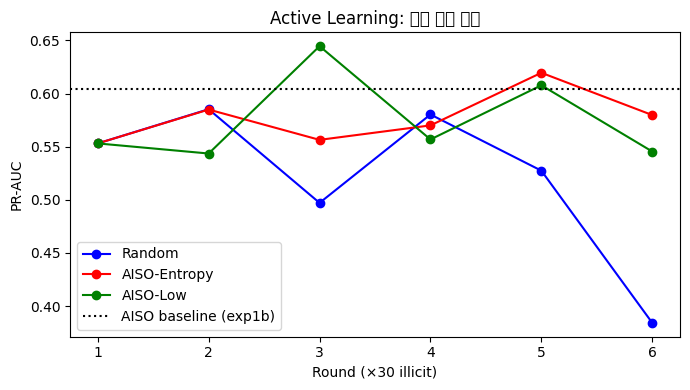

In [7]:
# AL 결과 테이블 + 시각화
print(f"{'Round':<7}", end="")
for s in curves: print(f"  {s:<14}", end="")
print(); print("-"*55)
for r in range(max(len(v) for v in curves.values())):
    print(f"  {r+1:<5}", end="")
    for s in curves:
        v = curves[s][r] if r < len(curves[s]) else float('nan')
        print(f"  {v:<14.4f}", end="")
    print()

plt.figure(figsize=(7,4))
for s,c in zip(curves, ['b','r','g']):
    x = range(1, len(curves[s])+1)
    plt.plot(x, curves[s], f'{c}o-', label=s)
plt.axhline(0.6041, color='k', linestyle=':', label='AISO baseline (exp1b)')
plt.xlabel("Round (×30 illicit)"); plt.ylabel("PR-AUC")
plt.title("Active Learning: 쿼리 전략 비교"); plt.legend(); plt.tight_layout(); plt.show()


## Exp 4c: Anomaly Detection (비지도, GNN 없음)

licit 학습 노드 3000개로만 AISO 표현 학습 → 테스트 노드 W_j 추정
이상 점수 = `-max_c(proto_W_c @ M @ W_j)` — 어느 licit 클러스터와도 안 맞으면 이상.
비교: Isolation Forest, LOF (동일 Dom-12 피처 기반)


In [8]:
# licit-only AISO
rng_licit = np.random.RandomState(SEED)
licit_samp = rng_licit.choice(train_licit_idx, 3000, replace=False)
W_licit, W_ag_l, M_l = learn_w(domain_norm_12[licit_samp], SEED=SEED)

# 테스트 노드 W_j 추정 (licit Ridge 기반)
reg_l = Ridge(alpha=0.1).fit(domain_norm_12[licit_samp], W_licit)
W_te = reg_l.predict(domain_norm_12[test_idx])
W_te = np.maximum(W_te,1e-8); W_te/=W_te.sum(1,keepdims=True)

# proto_W (licit 기준)
km_l = KMeans(8, random_state=SEED, n_init=10).fit(W_ag_l)
proto_l = km_l.cluster_centers_; proto_l/=proto_l.sum(1,keepdims=True)

# AISO 이상 점수
aiso_sc = np.array([-np.max(proto_l @ M_l @ W_te[j]) for j in range(len(test_idx))])
aiso_sc = (aiso_sc-aiso_sc.min())/(aiso_sc.max()-aiso_sc.min()+1e-8)

# Isolation Forest / LOF (동일 Dom-12 피처)
iso = IsolationForest(random_state=SEED, contamination=0.1)
iso.fit(domain_norm_12[licit_samp])
iso_sc = -iso.score_samples(domain_norm_12[test_idx])

lof = LocalOutlierFactor(novelty=True, contamination=0.1)
lof.fit(domain_norm_12[licit_samp])
lof_sc = -lof.score_samples(domain_norm_12[test_idx])

y_te = y_all[test_idx]
print(f"테스트: {len(y_te)}개  illicit={y_te.sum()}  licit={(y_te==0).sum()}")
print(f"  illicit 비율 (random 기준) = {y_te.mean():.4f}")
print()
print(f"{'방법':<22} {'PR-AUC':>8} {'ROC-AUC':>9}")
print("-"*42)
for nm, sc in [('AISO (licit-only)',aiso_sc),('Isolation Forest',iso_sc),('LOF',lof_sc)]:
    pr  = average_precision_score(y_te, sc)
    auc = roc_auc_score(y_te, sc)
    print(f"  {nm:<20} {pr:>8.4f} {auc:>9.4f}")
print(f"  {'Random baseline':<20} {y_te.mean():>8.4f}  (=illicit 비율)")


테스트: 16670개  illicit=1083  licit=15587
  illicit 비율 (random 기준) = 0.0650

방법                       PR-AUC   ROC-AUC
------------------------------------------
  AISO (licit-only)      0.2563    0.7434
  Isolation Forest       0.1800    0.7261
  LOF                    0.0406    0.2585
  Random baseline        0.0650  (=illicit 비율)


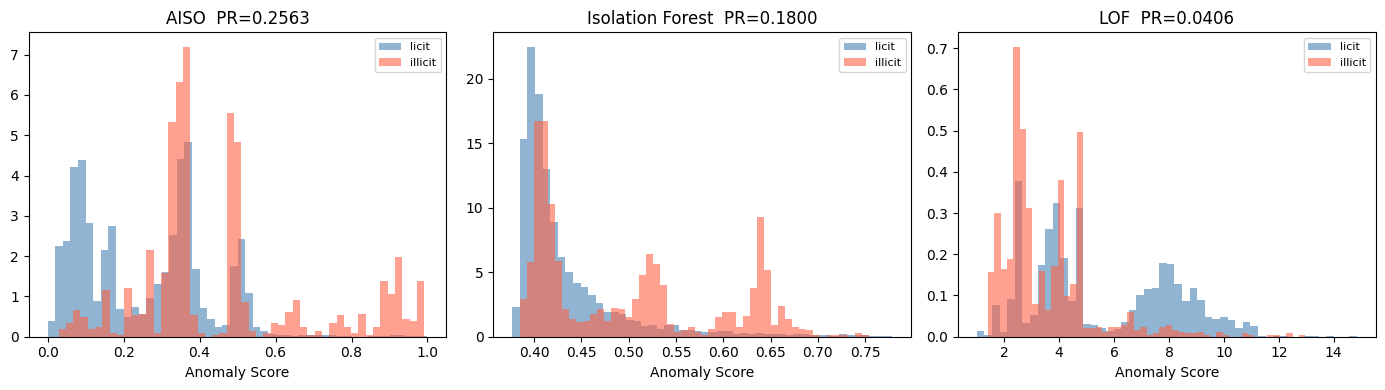

: 

In [ ]:
# 4c 분포 시각화
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax, nm, sc in zip(axes,
        ['AISO','Isolation Forest','LOF'],
        [aiso_sc, iso_sc, lof_sc]):
    ax.hist(sc[y_te==0],bins=50,alpha=0.6,label='licit',color='steelblue',density=True)
    ax.hist(sc[y_te==1],bins=50,alpha=0.6,label='illicit',color='tomato',density=True)
    pr = average_precision_score(y_te,sc)
    ax.set_title(f'{nm}  PR={pr:.4f}'); ax.legend(fontsize=8); ax.set_xlabel('Anomaly Score')
plt.tight_layout(); plt.show()
